# 下一课：Q-learning vs SARSA 对比实验

这一课我们不再只看单个算法，而是把 `Q-learning` 和 `SARSA` 放到同一个环境里训练，看看它们学出来的结果有什么不同。

这节课你会掌握：
- 两个算法的更新公式到底差在哪里
- 为什么 `Q-learning` 是 off-policy，`SARSA` 是 on-policy
- 在同一个小环境里，它们的学习曲线和 Q 表会有什么区别


## 1. 实验环境

我们继续用一维环境，但这次加一个更有教学意义的设定：

- 每走一步都会有一个小惩罚 `step_penalty = -0.02`
- 到达终点奖励是 `+1`
- 所以智能体不仅要到达终点，还要尽量少走弯路

这样 reward 曲线就不再只是 0 或 1，而是会随着策略变好慢慢上升。


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)
random.seed(42)
np.random.seed(42)


In [2]:
class PenalizedLineWorld:
    """
    一维走格子环境。
    每走一步都会有小惩罚，到达终点给正奖励。
    """

    def __init__(self, length=6, step_penalty=-0.02, goal_reward=1.0):
        self.length = length
        self.goal = length - 1
        self.step_penalty = step_penalty
        self.goal_reward = goal_reward
        self.reset()

    def reset(self):
        self.position = 0
        return self.position

    def step(self, action):
        if action == 0:
            self.position = max(0, self.position - 1)
        else:
            self.position = min(self.goal, self.position + 1)

        done = self.position == self.goal
        reward = self.goal_reward if done else self.step_penalty
        return self.position, reward, done

    def render(self):
        cells = ['.'] * self.length
        cells[self.goal] = 'G'
        if self.position != self.goal:
            cells[self.position] = 'A'
        else:
            cells[self.position] = 'A/G'
        return ' '.join(cells)


## 2. 先看两个公式

`Q-learning`：

$Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$

`SARSA`：

$Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma Q(s', a') - Q(s, a)]$

差别只在目标值那一项：

- `Q-learning` 看的是下一状态里“最好的动作”
- `SARSA` 看的是下一步“实际会执行的动作”

这一个小差别，就是它们性格不同的根源。


In [3]:
def choose_action(state, q_table, epsilon):
    if random.random() < epsilon:
        return random.randint(0, 1)

    best_actions = np.flatnonzero(q_table[state] == np.max(q_table[state]))
    return int(random.choice(best_actions))


def train_q_learning(env, episodes=300, alpha=0.1, gamma=0.9, epsilon=0.3, max_steps=40):
    q_table = np.zeros((env.length, 2))
    rewards = []
    steps_history = []

    for _ in range(episodes):
        state = env.reset()
        total_reward = 0

        for step in range(max_steps):
            action = choose_action(state, q_table, epsilon)
            next_state, reward, done = env.step(action)

            old_value = q_table[state, action]
            next_best = 0 if done else np.max(q_table[next_state])
            target = reward + gamma * next_best
            q_table[state, action] = old_value + alpha * (target - old_value)

            state = next_state
            total_reward += reward

            if done:
                steps_history.append(step + 1)
                break
        else:
            steps_history.append(max_steps)

        rewards.append(total_reward)
        epsilon = max(0.02, epsilon * 0.995)

    return q_table, rewards, steps_history


def train_sarsa(env, episodes=300, alpha=0.1, gamma=0.9, epsilon=0.3, max_steps=40):
    q_table = np.zeros((env.length, 2))
    rewards = []
    steps_history = []

    for _ in range(episodes):
        state = env.reset()
        action = choose_action(state, q_table, epsilon)
        total_reward = 0

        for step in range(max_steps):
            next_state, reward, done = env.step(action)
            old_value = q_table[state, action]
            total_reward += reward

            if done:
                target = reward
                q_table[state, action] = old_value + alpha * (target - old_value)
                steps_history.append(step + 1)
                break

            next_action = choose_action(next_state, q_table, epsilon)
            target = reward + gamma * q_table[next_state, next_action]
            q_table[state, action] = old_value + alpha * (target - old_value)

            state = next_state
            action = next_action
        else:
            steps_history.append(max_steps)

        rewards.append(total_reward)
        epsilon = max(0.02, epsilon * 0.995)

    return q_table, rewards, steps_history


In [4]:
env_q = PenalizedLineWorld(length=6, step_penalty=-0.02, goal_reward=1.0)
env_s = PenalizedLineWorld(length=6, step_penalty=-0.02, goal_reward=1.0)

q_q_learning, rewards_q, steps_q = train_q_learning(env_q)
q_sarsa, rewards_s, steps_s = train_sarsa(env_s)

print('Q-learning 最终 Q 表：')
print(q_q_learning)
print()
print('SARSA 最终 Q 表：')
print(q_sarsa)


Q-learning 最终 Q 表：
[[0.442 0.587]
 [0.319 0.675]
 [0.561 0.772]
 [0.639 0.88 ]
 [0.657 1.   ]
 [0.    0.   ]]

SARSA 最终 Q 表：
[[0.321 0.574]
 [0.292 0.669]
 [0.393 0.771]
 [0.491 0.88 ]
 [0.543 1.   ]
 [0.    0.   ]]


In [5]:
action_map = {0: '←', 1: '→'}

policy_q = [action_map[int(np.argmax(q_q_learning[s]))] for s in range(env_q.length - 1)] + ['G']
policy_s = [action_map[int(np.argmax(q_sarsa[s]))] for s in range(env_s.length - 1)] + ['G']

print('Q-learning 学到的策略：')
for s, a in enumerate(policy_q):
    print(f'状态 {s}: {a}')

print()
print('SARSA 学到的策略：')
for s, a in enumerate(policy_s):
    print(f'状态 {s}: {a}')


Q-learning 学到的策略：
状态 0: →
状态 1: →
状态 2: →
状态 3: →
状态 4: →
状态 5: G

SARSA 学到的策略：
状态 0: →
状态 1: →
状态 2: →
状态 3: →
状态 4: →
状态 5: G


C:\Users\80740\AppData\Local\Temp\ipykernel_43272\1061112542.py:21: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_43272\1061112542.py:21: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_43272\1061112542.py:21: UserWarning: Glyph 22870 (\N{CJK UNIFIED IDEOGRAPH-5956}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_43272\1061112542.py:21: UserWarning: Glyph 21169 (\N{CJK UNIFIED IDEOGRAPH-52B1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_43272\1061112542.py:21: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_43272\1061112542.py:21: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4})

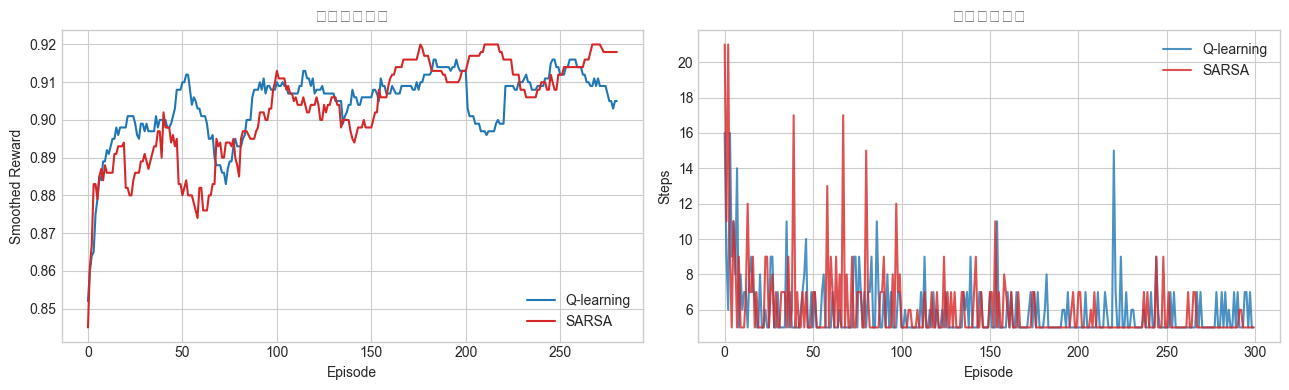

In [6]:
window = 20
smoothed_q = np.convolve(rewards_q, np.ones(window) / window, mode='valid')
smoothed_s = np.convolve(rewards_s, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(smoothed_q, label='Q-learning', color='#1f77b4')
axes[0].plot(smoothed_s, label='SARSA', color='#d62728')
axes[0].set_title('平均奖励对比')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Smoothed Reward')
axes[0].legend()

axes[1].plot(steps_q, label='Q-learning', color='#1f77b4', alpha=0.8)
axes[1].plot(steps_s, label='SARSA', color='#d62728', alpha=0.8)
axes[1].set_title('每轮步数对比')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps')
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. 怎么理解实验结果

你大概率会看到：

- 两个算法最后都能学会一直向右走到终点
- 但它们中间的学习过程不一定完全一样
- `SARSA` 因为会把“当前探索策略”也考虑进去，所以往往显得更保守一点
- `Q-learning` 因为总是假设下一步能拿最优动作，所以常常更乐观一些

在这个简单环境里，它们最后看起来会很像；但在更复杂、更危险的环境里，这种差别会变得很明显。


## 4. 这一课记住这三句话

1. `Q-learning` 学的是“如果下一步总选最优动作，会怎么样”。
2. `SARSA` 学的是“按照我当前真的会怎么走，会怎么样”。
3. 在简单环境里它们可能很像，但在复杂环境里行为风格会不同。

最适合的下一课是：
- `Cliff Walking` 悬崖环境
- `GridWorld` 二维网格环境
- OpenAI Gym / Gymnasium 的 `FrozenLake`
